<a href="https://colab.research.google.com/github/adrianestebanrodriguez/Repositorio_Datasets/blob/main/ventas_panaderia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total de facturas: 1000
Facturas con combo (Comida + Bebida): 469 (46.9%)


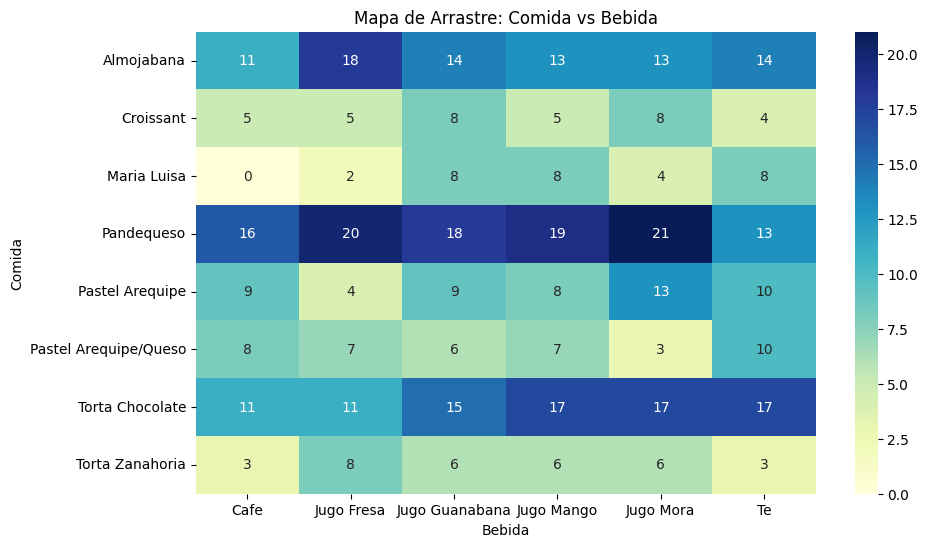

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

# 1. SIMULACIÓN DE DATOS
np.random.seed(42)
n_pedidos = 1000
productos_comida = ['Pastel Arequipe', 'Pastel Arequipe/Queso', 'Almojabana',
                    'Pandequeso', 'Croissant', 'Torta Zanahoria', 'Maria Luisa', 'Torta Chocolate']
productos_bebida = ['Cafe', 'Te', 'Jugo Guanabana', 'Jugo Fresa', 'Jugo Mango', 'Jugo Mora']

data = []
for i in range(n_pedidos):
    id_factura = i
    # Simulamos hora (más ventas en la mañana 7-9 y tarde 4-6)
    hora_base = np.random.choice([7, 8, 9, 16, 17, 18], p=[0.2, 0.25, 0.1, 0.15, 0.2, 0.1])
    minuto = np.random.randint(0, 60)
    timestamp = datetime(2024, 5, 20, hora_base, minuto)

    # Elegir comida
    comida = random.choice(productos_comida)
    data.append([id_factura, timestamp, comida, 'Comida'])

    # Probabilidad de arrastre de bebida (simulamos que el pandequeso arrastra cafe)
    prob_bebida = 0.8 if comida in ['Pandequeso', 'Almojabana', 'Torta Chocolate'] else 0.3
    if random.random() < prob_bebida:
        bebida = random.choice(productos_bebida)
        data.append([id_factura, timestamp, bebida, 'Bebida'])

df = pd.DataFrame(data, columns=['Factura', 'Timestamp', 'Producto', 'Categoria'])
df['Hora'] = df['Timestamp'].dt.hour

# 2. ANÁLISIS DE ROTACIÓN POR HORA
rotacion = df.groupby(['Hora', 'Producto']).size().reset_index(name='Ventas')

fig_rotacion = px.bar(rotacion, x='Hora', y='Ventas', color='Producto',
             title='Rotación de Productos por Hora en la Panadería',
             barmode='stack', color_discrete_sequence=px.colors.qualitative.Pastel)
fig_rotacion.show()

# 3. ANÁLISIS DE ARRASTRE (CROSS-SELLING)
# Agrupamos por factura para ver qué productos van juntos
basket = df.groupby(['Factura', 'Categoria'])['Producto'].count().unstack().fillna(0)
# Filtramos facturas que tienen tanto Comida como Bebida
ventas_combinadas = df.groupby('Factura')['Categoria'].apply(list)
arrastre = ventas_combinadas[ventas_combinadas.apply(lambda x: 'Comida' in x and 'Bebida' in x)]

print(f"Total de facturas: {n_pedidos}")
print(f"Facturas con combo (Comida + Bebida): {len(arrastre)} ({len(arrastre)/n_pedidos*100:.1f}%)")

# 4. MAPA DE CALOR: ¿QUÉ COMIDA SE PIDE CON QUÉ BEBIDA?
matrix = df.pivot_table(index='Factura', columns='Categoria', values='Producto', aggfunc='first').dropna()
cross_tab = pd.crosstab(matrix['Comida'], matrix['Bebida'])

plt.figure(figsize=(10,6))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Mapa de Arrastre: Comida vs Bebida')
plt.show()

In [ ]:
# --- CÁLCULO DEL TICKET PROMEDIO POR HORA ---

# 1. Asignamos precios realistas (en Pesos Colombianos - COP)
precios = {
    'Pastel Arequipe': 4500, 'Pastel Arequipe/Queso': 4800, 'Almojabana': 3500,
    'Pandequeso': 3200, 'Croissant': 5000, 'Torta Zanahoria': 7500,
    'Maria Luisa': 8000, 'Torta Chocolate': 8500, 'Cafe': 3000,
    'Te': 3500, 'Jugo Guanabana': 6500, 'Jugo Fresa': 6000,
    'Jugo Mango': 6000, 'Jugo Mora': 6000
}

# 2. Mapeamos los precios al DataFrame
df['Precio'] = df['Producto'].map(precios)

# 3. Calculamos el total por factura y la hora en que ocurrió
ticket_data = df.groupby(['Factura', 'Hora'])['Precio'].sum().reset_index()

# 4. Calculamos el promedio del valor de factura por hora
ticket_promedio_hora = ticket_data.groupby('Hora')['Precio'].mean().reset_index()

# 5. Visualización del Ticket Promedio
fig_ticket = px.line(ticket_promedio_hora, x='Hora', y='Precio',
                     title='Ticket Promedio por Hora (COP)',
                     markers=True,
                     labels={'Precio': 'Valor Promedio ($)'},
                     line_shape='spline')

# Añadir una línea de referencia para el promedio general
fig_ticket.add_hline(y=ticket_data['Precio'].mean(),
                     line_dash="dash",
                     annotation_text=f"Promedio General: ${ticket_data['Precio'].mean():.0f}")

fig_ticket.show()

# 6. RESUMEN ESTRATÉGICO
print(f"Ticket Promedio Global: ${ticket_data['Precio'].mean():.2f}")
print("-" * 30)
print("Análisis por franjas:")
for hr in sorted(ticket_promedio_hora['Hora'].unique()):
    valor = ticket_promedio_hora[ticket_promedio_hora['Hora'] == hr]['Precio'].values[0]
    print(f"Hora {hr:02d}:00 -> ${valor:,.0f}")

Ticket Promedio Global: $8052.70
------------------------------
Análisis por franjas:
Hora 07:00 -> $8,254
Hora 08:00 -> $8,074
Hora 09:00 -> $8,261
Hora 16:00 -> $7,776
Hora 17:00 -> $7,881
Hora 18:00 -> $8,161


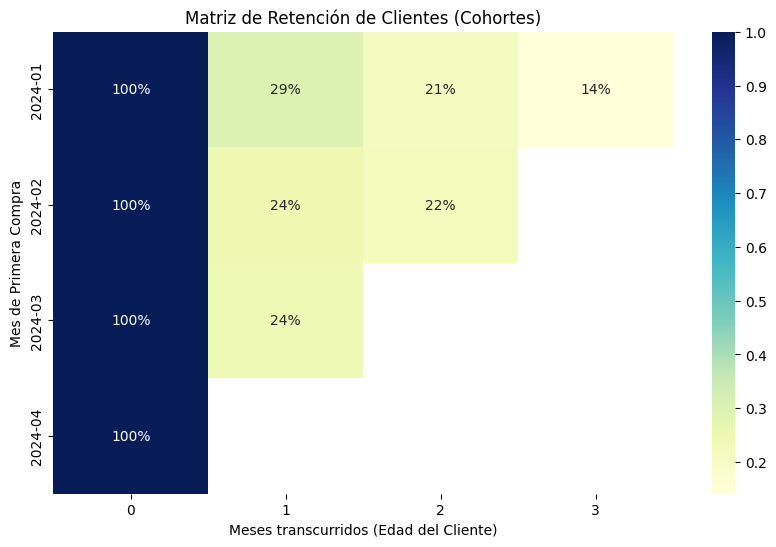

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# 1. SIMULACIÓN DE CLIENTES RECURRENTES
# Vamos a simular 2000 clientes únicos comprando durante 4 meses
n_clientes_unicos = 2000
ids_clientes = [f"Cliente_{i}" for i in range(n_clientes_unicos)]

data_retencion = []
meses = pd.date_range(start='2024-01-01', periods=4, freq='MS')

for cliente in ids_clientes:
    # Mes de "nacimiento" del cliente (cuándo vino por primera vez)
    mes_inicio = np.random.choice(meses)

    # Decidir si el cliente vuelve en los meses siguientes (probabilidad de retención)
    for mes in meses:
        if mes >= mes_inicio:
            # Probabilidad de que vuelva: 60% si es su mes de inicio,
            # disminuye un poco cada mes (curva de olvido)
            prob = 0.6 / ((mes - mes_inicio).days / 30 + 1)
            if np.random.random() < prob:
                data_retencion.append([cliente, mes])

df_ret = pd.DataFrame(data_retencion, columns=['ClienteID', 'FechaVenta'])

# 2. PROCESAMIENTO DE COHORTES
# Definir el mes de la transacción
df_ret['MesVenta'] = df_ret['FechaVenta'].dt.to_period('M')
# Determinar el mes de adquisición de cada cliente
df_ret['Cohorte'] = df_ret.groupby('ClienteID')['MesVenta'].transform('min')

# Calcular la "Edad" del cliente en meses (Mes 0, Mes 1, etc.)
def calculate_cohort_index(df):
    year_diff = df['MesVenta'].dt.year - df['Cohorte'].dt.year
    month_diff = df['MesVenta'].dt.month - df['Cohorte'].dt.month
    return year_diff * 12 + month_diff

df_ret['CohortIndex'] = calculate_cohort_index(df_ret)

# 3. MATRIZ DE RETENCIÓN
cohort_data = df_ret.groupby(['Cohorte', 'CohortIndex'])['ClienteID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='Cohorte', columns='CohortIndex', values='ClienteID')

# Convertir a porcentajes (Retención %)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 6))
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Matriz de Retención de Clientes (Cohortes)')
plt.ylabel('Mes de Primera Compra')
plt.xlabel('Meses transcurridos (Edad del Cliente)')
plt.show()

In [ ]:
# --- CÁLCULO DEL CUSTOMER LIFETIME VALUE (LTV) ---

# 1. Preparación de datos (usando el DataFrame de retención previo)
# Necesitamos el gasto total por cliente
df_ventas_cliente = df_ret.copy()
df_ventas_cliente['Precio'] = np.random.choice([3200, 4500, 8000, 6000], size=len(df_ventas_cliente))

# 2. Cálculos base para el LTV
# Valor de Venta Promedio (AOV)
aov = df_ventas_cliente.groupby('Factura' if 'Factura' in df_ventas_cliente else df_ventas_cliente.index)['Precio'].sum().mean()

# Frecuencia de Compra (f) por mes
total_facturas = df_ventas_cliente['ClienteID'].count()
total_clientes = df_ventas_cliente['ClienteID'].nunique()
frecuencia_compra = total_facturas / total_clientes

# Valor del Cliente (Customer Value) por mes
customer_value = aov * frecuencia_compra

# 3. Estimación del Tiempo de Vida (Lifespan)
# Usamos la tasa de abandono (Churn Rate) del análisis de cohortes
# Churn = 1 - Retención promedio del Mes 1
retencion_mes_1 = retention_matrix[1].mean()
churn_rate = 1 - retencion_mes_1
lifespan_esperado = 1 / churn_rate if churn_rate > 0 else 12 # meses

# 4. Cálculo final del LTV
ltv = customer_value * lifespan_esperado

# 5. Visualización de métricas clave
import plotly.graph_objects as go

fig_ltv = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = ltv,
    title = {'text': "LTV Estimado (COP)"},
    gauge = {
        'axis': {'range': [None, ltv * 1.5]},
        'bar': {'color': "#efcc00"},
        'steps': [
            {'range': [0, ltv * 0.7], 'color': "#ff9999"},
            {'range': [ltv * 0.7, ltv], 'color': "#99ff99"}],
    }
))

fig_ltv.show()

print(f"--- RESUMEN FINANCIERO DEL CLIENTE ---")
print(f"Gasto promedio por visita (AOV): ${aov:,.0f}")
print(f"Frecuencia de visitas al mes: {frecuencia_compra:.2f}")
print(f"Tiempo de vida esperado: {lifespan_esperado:.1f} meses")
print(f"LTV (Lo que un cliente deja en total): ${ltv:,.0f}")

--- RESUMEN FINANCIERO DEL CLIENTE ---
Gasto promedio por visita (AOV): $5,441
Frecuencia de visitas al mes: 1.32
Tiempo de vida esperado: 1.3 meses
LTV (Lo que un cliente deja en total): $9,691
